#Cycling Infrastructure Analysis

## Package installation and import

In [1]:
!pip install osmnx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.2 MB/s eta 0:00:00


In [2]:
#import libraries

import osmnx as ox
import networkx as nx
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from google.colab import files

## Load study area and create network

In [3]:
#created study area in QGIS using PDOK to load wijken and selcting wijken
#determined that binnestad + adjcaent wijken suitable
#reduced scale to buurten for more fine-grained analysis

#scale = 'wijk'
scale = 'buurt'

if scale == "wijk":
  name = 'wijknaam'
elif scale == "buurt":
  name = 'buurtnaam'

study_area = gpd.read_file(f"study_area_by_{scale}.gpkg")
#print(study_area.crs)

In [4]:
#osmnx expects geometries in 4326 (world geodetic system)
study_area_wgs = study_area.to_crs(epsg=4326)

#print(study_area_wgs.is_valid)
#print(study_area_wgs.head())

#create network graph within the study area

from shapely.ops import unary_union
polygon = unary_union(study_area_wgs.geometry)

G = ox.graph_from_polygon(polygon,network_type="bike",simplify=True)
G_proj = ox.project_graph(G, to_crs='EPSG:28992')

nodes,edges=ox.graph_to_gdfs(G_proj)

## Calculate each metric

### Demand/Human Activity

OAD - "Environmental address density is expressed in addresses per square kilometer and aims to reflect the concentration of human activities (living, working, going to school, shopping, going out, etc.)"

In [5]:
study_area['demand_intensity'] = study_area['omgevingsadressendichtheid']

### Transport vulnerability

Cars per housheold for dependence on cycling

In [6]:
#Replace missing data point with the average of surrounding buurten

study_area['personenautosPerHuishouden'] = (
    study_area['personenautosPerHuishouden']
    .replace(-99997, 0.6)
)

In [7]:
# invert direction and let z-score standardization handle scaling

study_area['transport_vulnerability'] = -study_area['personenautosPerHuishouden']

### Coverage

In [8]:
#50m buffer to cycle lanes
cycle_buffer = edges.buffer(50)

buffer_area = cycle_buffer.unary_union #dissolve into one area

buffer_gdf = gpd.GeoDataFrame(geometry=[buffer_area], crs=edges.crs)

/tmp/ipykernel_575/539719332.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_area = cycle_buffer.unary_union #dissolve into one area


In [9]:
#intersection to compute covered population
covered = gpd.overlay(study_area, buffer_gdf, how='intersection')

covered['area_fragment'] = covered.geometry.area
study_area['area'] = study_area.geometry.area

study_area['covered_frac'] = covered['area_fragment']/study_area['area']
study_area['covered_pop'] = study_area['aantalInwoners'] * study_area['covered_frac']

### Intersection Density

"Defined as the number of street intersections per unit of land area (typically per square kilometer or square mile). It serves as a key measure of street network connectivity, permeability, and walkability. Higher intersection density suggests smaller block sizes and more direct, diverse, and shorter routes for pedestrians and vehicles."

In [10]:
study_area = study_area.set_index(name)

In [11]:
#nodes with degree >= 3
node_degree = pd.Series(dict(G_proj.degree()))
intersection_nodes = node_degree[node_degree >= 3].index

# gdf of intersections
intersection_gdf = nodes.loc[intersection_nodes]
intersection_gdf = intersection_gdf.to_crs(study_area.crs)

# assign intersections to buurten - sjoin spatially assign each point to a polygon
# keep ALL rows from the left df and attach attributes from the right df where they match.
intersection_gdf = gpd.sjoin(intersection_gdf, study_area, how='left', predicate='within')

# intersections per buurt
intersection_count = intersection_gdf.groupby(name).size() #name is here e.g. buurtnaam

#print(intersection_count.sort_values(ascending=False))

# density
study_area['intersection_density'] = (
    intersection_count
    .reindex(study_area.index)
    / study_area['area']
)

#print(study_area['intersection_density'].sort_values(ascending=False))

## Plot Unscaled metrics

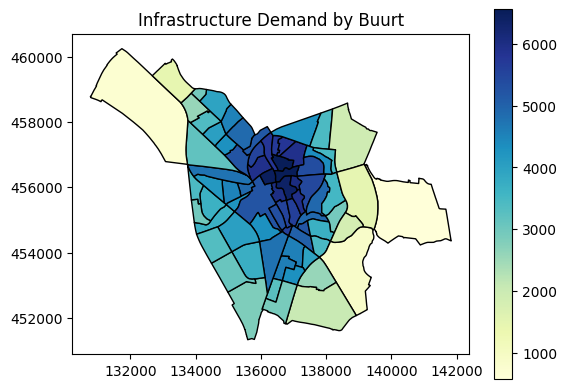

In [12]:
#choropleth map of demand intensity
study_area.plot(column='demand_intensity',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Infrastructure Demand by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

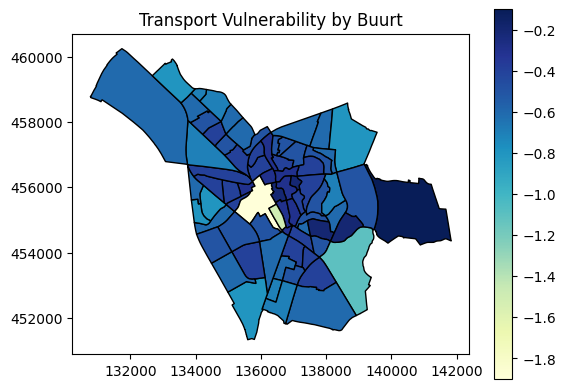

In [13]:
#choropleth map of transport vulnerability
study_area.plot(column='transport_vulnerability',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Transport Vulnerability by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

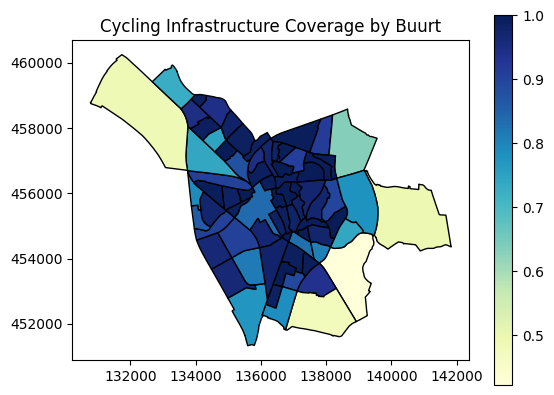

In [14]:
#choropleth map of coverage
study_area.plot(column='covered_frac',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Cycling Infrastructure Coverage by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

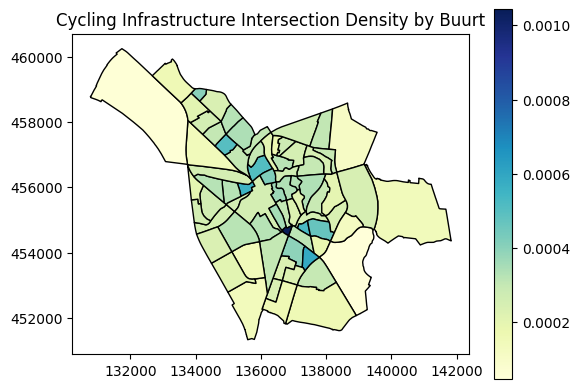

In [15]:
#choropleth map of intersection density
study_area.plot(column='intersection_density',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Cycling Infrastructure Intersection Density by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

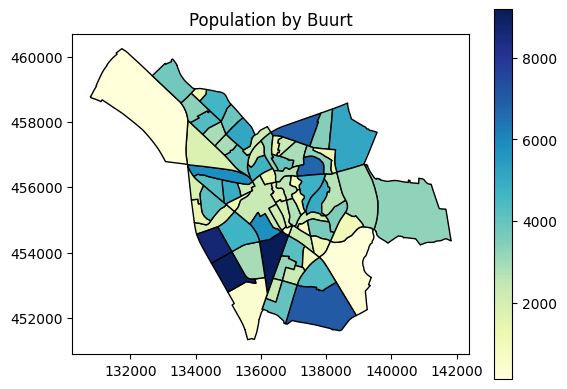

In [16]:
#choropleth map of population
study_area.plot(column='aantalInwoners',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Population by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

## Scale Metrics & plot scaled

z-score standardisation

Z = (X - mean(X)) / std(X)


Mean becomes 0

Standard deviation becomes 1

But the min and max depend on the data distribution and outliers

In [17]:
from sklearn.preprocessing import StandardScaler

#properties to standardise
cols_to_standardize = ['demand_intensity', 'covered_frac', 'transport_vulnerability',  'intersection_density', 'aantalInwoners']

scaler = StandardScaler()
std_values = scaler.fit_transform(study_area[cols_to_standardize])

#put back into dataframe
for i, col in enumerate(cols_to_standardize):
    study_area[col + '_std'] = std_values[:, i]

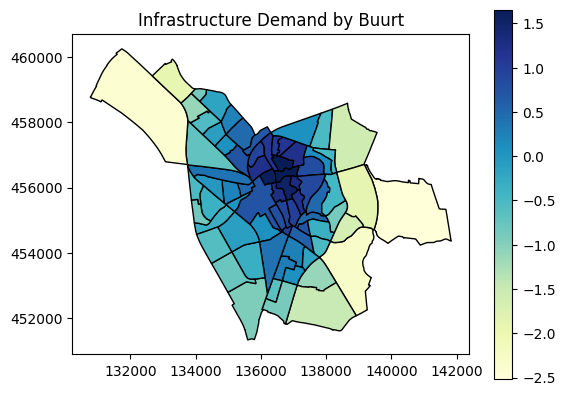

In [18]:
#choropleth map of demand intensity
study_area.plot(column='demand_intensity_std',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Infrastructure Demand by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

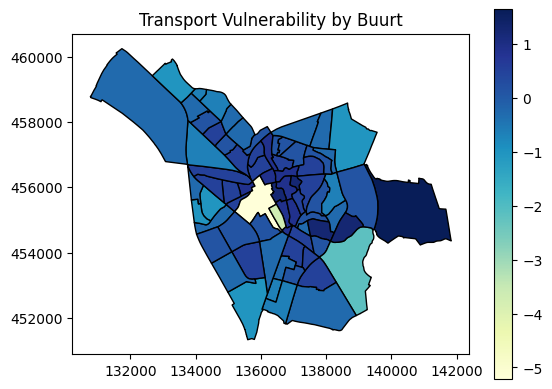

In [19]:
#choropleth map of transport vulnerability
study_area.plot(column='transport_vulnerability_std',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Transport Vulnerability by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

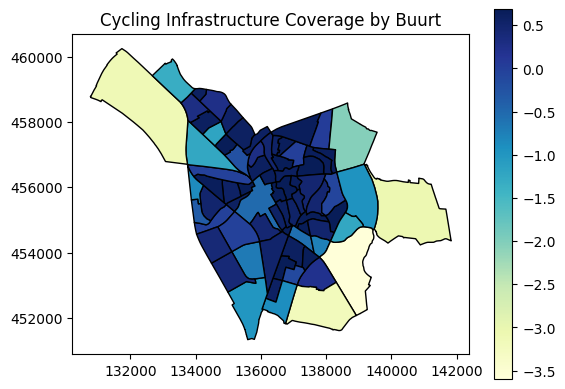

In [20]:
#choropleth map of coverage
study_area.plot(column='covered_frac_std',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Cycling Infrastructure Coverage by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

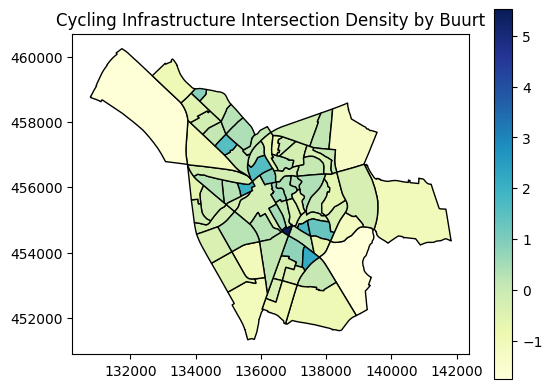

In [21]:
#choropleth map of intersection density
study_area.plot(column='intersection_density_std',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Cycling Infrastructure Intersection Density by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

## Equity + Priority score calculation & Plots

Z-scores don’t need to be “all positive” for composite indices:

Standardization centers around 0

Adding and subtracting metrics works naturally

In [22]:
w_coverage = 0.7
w_transport = 0.3
w_population = 0.5

###Coverage gap

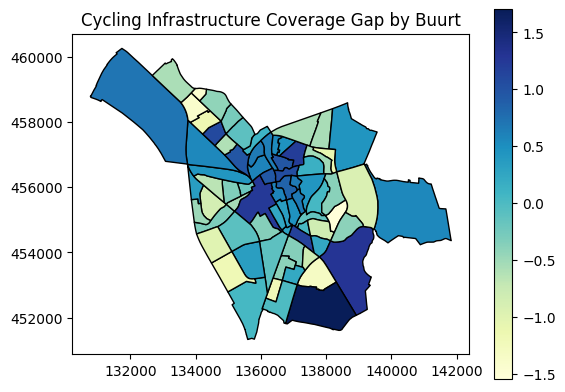

In [23]:
study_area['coverage_gap'] = study_area['demand_intensity_std'] - study_area['covered_frac_std']

study_area.plot(column='coverage_gap',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Cycling Infrastructure Coverage Gap by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

### Equity score

high where demand/vulnerability is high AND infrastructure is poor


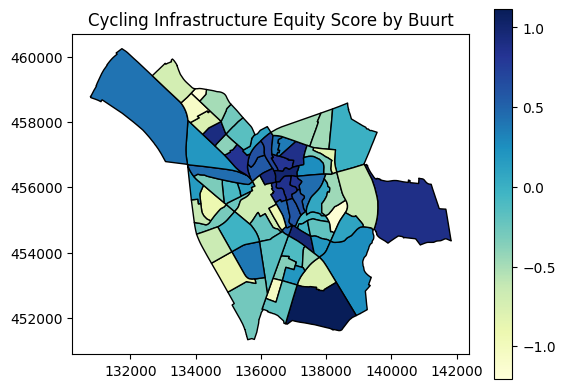

In [24]:
study_area['equity_score'] = (
    w_coverage * study_area['coverage_gap'] +
    w_transport * study_area['transport_vulnerability_std']
)


#choropleth map of equity
study_area.plot(column='equity_score',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Cycling Infrastructure Equity Score by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

### Priority Score

scale equity by number of people affected

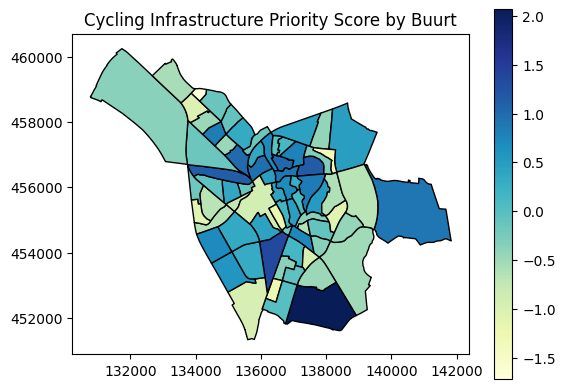

In [25]:
# Priority score = scale equity score by number of people affected
study_area['priority_score'] = study_area['equity_score'] + w_population * study_area['aantalInwoners_std']

#choropleth map of priority score
study_area.plot(column='priority_score',
                cmap='YlGnBu',
                legend=True,
                edgecolor='black')

plt.title(f"Cycling Infrastructure Priority Score by {scale.capitalize()}")
#ax.set_axis_off()

plt.show()

## Plot study area & Connectivity

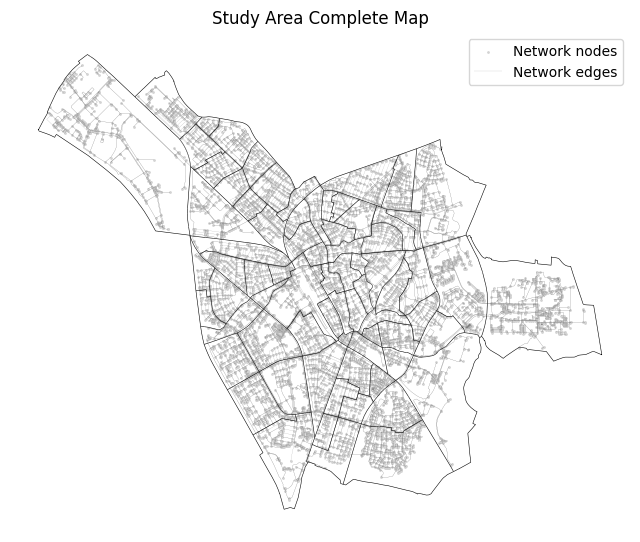

'\nfig.savefig(\n    "study_area_destinations.png",\n    dpi=600,\n    bbox_inches="tight",\n)\n'

In [26]:
#plot study area - boundaries, network, key points

fig, ax = plt.subplots(figsize=(8, 8))


#network nodes
nodes.plot(
    ax=ax,
    markersize=1,
    color="lightgrey",
    label="Network nodes"
)

#network edges - cycling lanes
edges.plot(
    ax=ax,
    color='grey',
    linewidth = 0.1,
    label = 'Network edges'
)



merged_boundaries = unary_union(study_area.boundary)
gpd.GeoSeries(merged_boundaries).plot(
    ax=ax,
    color="black",
    linewidth=0.4,
)

'''
#plot polygons (outlined)
study_area.boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4,
    alpha=1,
    label=f"{scale.capitalize()} boundaries"
)
'''

ax.legend()
ax.set_title("Study Area Complete Map")
ax.set_axis_off()

plt.show()

'''
fig.savefig(
    "study_area_destinations.png",
    dpi=600,
    bbox_inches="tight",
)
'''


### Compute connectivity

In [27]:
#visualise fragmentation/subnetworks

#identify connected components in the network
components = list(nx.connected_components(G_proj.to_undirected()))

#number of isolated subnetworks
num_components = len(components)

#mark which nodes/edges belong to which component
component_map = {}
for i, comp in enumerate(components):
    for node in comp:
        component_map[node] = i

In [28]:
print(len(components))
print([len(c) for c in components])

#there is only one component - fully connected network
#this makes sense given that roads have been used too, and the density

1
[10710]


In [29]:
#add component info to nodes GeoDataFrame
nodes['component'] = nodes.index.map(component_map)

#add component info to edges GeoDataFrame
edge_components = []

for u, v, key, data in G_proj.edges(keys=True, data=True):
    edge_components.append(component_map[u])

#assign to edges
edges['component'] = edge_components


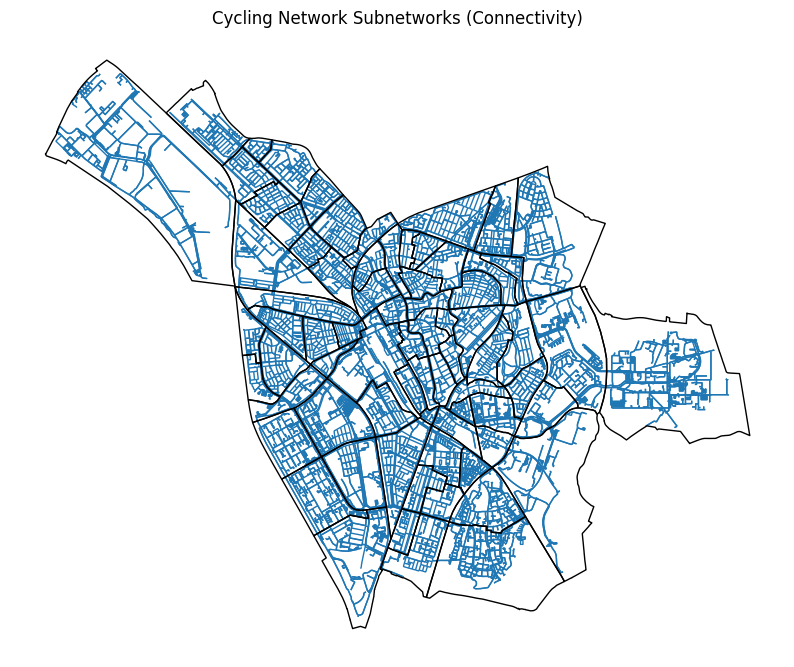

In [30]:
#print subnetworks coloured

fig, ax = plt.subplots(figsize=(10, 10))

edges.plot(
    ax=ax,
    column='component',
    categorical=True,
    linewidth=1,
    legend=False
)

study_area.boundary.plot(ax=ax, color='black', linewidth=1)

ax.set_title("Cycling Network Subnetworks (Connectivity)")
ax.axis('off')
plt.show()


## Final Plots

int: coverage gap, transport vulnerability, population

Equity score

Priority score

In [31]:
#colorscale

from matplotlib.colors import LinearSegmentedColormap

colors = [
    "#415887", #darkblue
    "#4986C1", #brightblue
    #"#8AA1C8", #lightblue
    #"#CBBED0",
    "#7F6A8B", #midpurple
    #"#3F2A48",
    "#BB7D8F", #lightpurplered
    #"#77334D", #purple-red
    "#AF3B4D" #darkred
]

cmap = LinearSegmentedColormap.from_list("custom_map", colors)


plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Nimbus Roman", "DejaVu Serif"]
plt.rcParams["font.size"] = 10

### Scale Metrics 0-1

Just for plotting purpose - no subsequent computation

In [32]:
from sklearn.preprocessing import MinMaxScaler

#properties to standardise - don't scale population
cols_to_standardize = ['coverage_gap', 'transport_vulnerability',  'equity_score', 'priority_score']

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(study_area[cols_to_standardize])

#put back into dataframe
for i, col in enumerate(cols_to_standardize):
    study_area[col + '_scaled'] = scaled_values[:, i]

### Intermediate metric plots

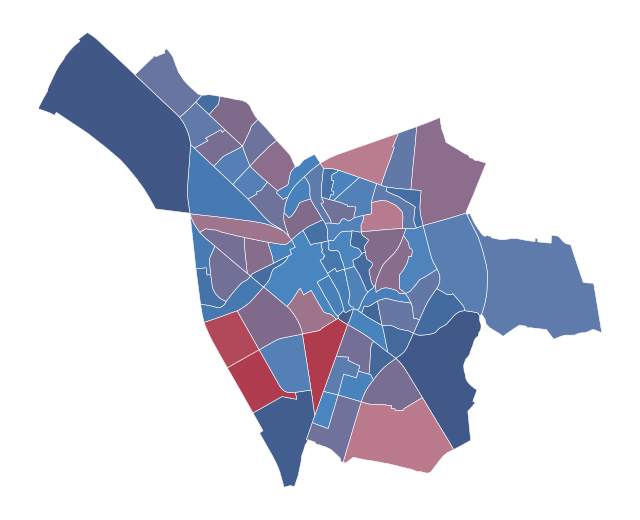

In [33]:
#choropleth map of Population
fig, ax = plt.subplots(figsize=(8, 8))

study_area.plot(
    column='aantalInwoners',
    cmap=cmap,
    edgecolor='white',
    linewidth=0.4,
    #legend=True,
    legend_kwds={
        "shrink": 0.2,
        "ticks": [0, 2000, 4000, 6000, 8000],
    },
    ax=ax
)

ax.set_axis_off()

plt.show()


fig.savefig(
    "chloropleth_population.png",
    dpi=600,
    bbox_inches="tight",
)


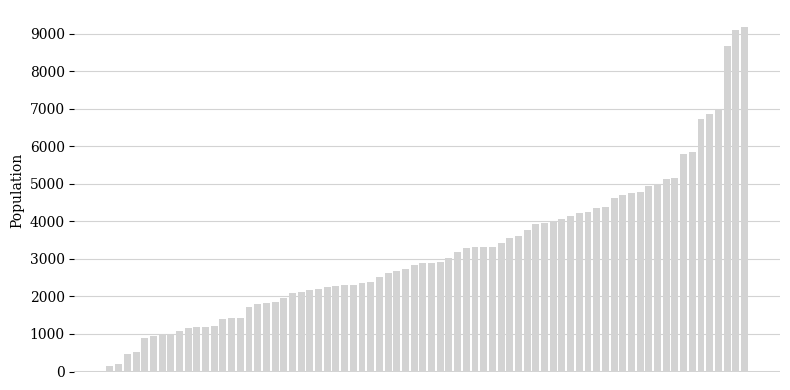

In [34]:
sorted_population = study_area.sort_values(by="aantalInwoners")

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    sorted_population.index,
    sorted_population["aantalInwoners"],
    color = 'lightgrey'
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.axhline(0, color='lightgrey',zorder=0)

# Add horizontal lines (grid lines)
ax.grid(visible=True, axis='y',color='lightgrey')
ax.set_axisbelow(True)

ax.set_ylabel("Population")
yticks = np.arange(0, 10000, 1000)
ax.set_yticks(yticks)

ax.set_xticks([])

plt.tight_layout()
plt.show()



fig.savefig(
    "barchart_population.png",
    dpi=600,
    bbox_inches="tight",
)


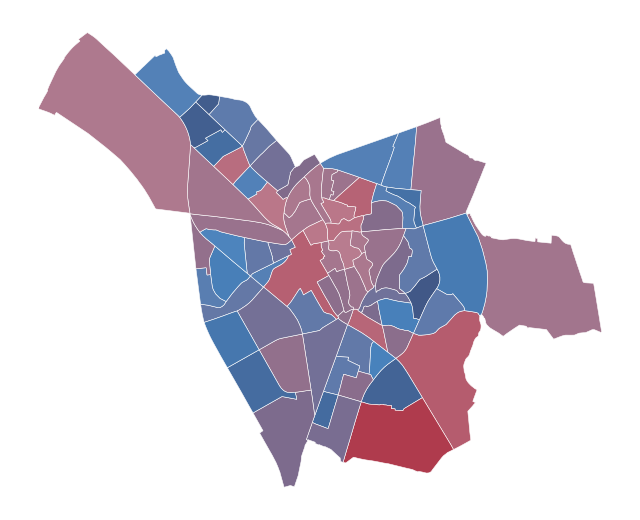

In [45]:
#choropleth map of coverage gap
fig, ax = plt.subplots(figsize=(8, 8))

plot = study_area.plot(
    column='coverage_gap_scaled',
    cmap=cmap,
    edgecolor='white',
    linewidth=0.4,
    #legend=True,
    legend_kwds={"shrink": 0.5},
    ax=ax
)

'''
cbar = plot.get_figure().axes[1]
cbar.set_yticks([])
#cbar.set_yticks([0, 0.5, 1])
#cbar.set_yticklabels(["Small gap", "Medium", "Large gap"])
'''

ax.set_axis_off()

plt.show()


fig.savefig(
    "chloropleth_coverage_gap.png",
    dpi=600,
    bbox_inches="tight",
)


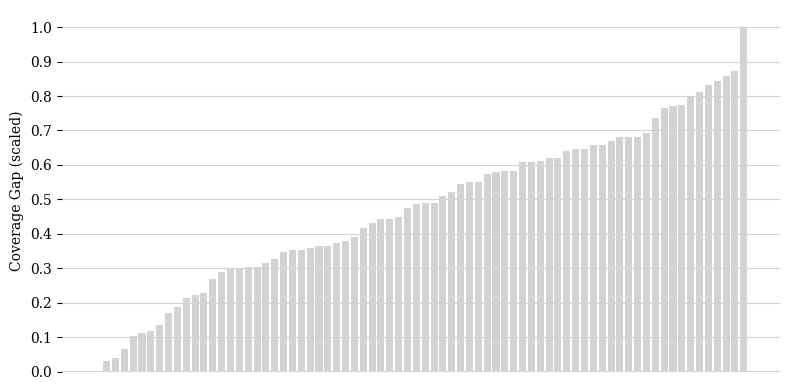

In [36]:
sorted_coverage = study_area.sort_values(by="coverage_gap_scaled")

fig, ax = plt.subplots(figsize=(8, 4))


ax.bar(
    sorted_coverage.index,
    sorted_coverage["coverage_gap_scaled"],
    color = 'lightgrey'
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.axhline(0, color='lightgrey',zorder=0)

# Add horizontal lines (grid lines)
ax.grid(visible=True, axis='y',color='lightgrey')
ax.set_axisbelow(True)

ax.set_ylabel("Coverage Gap (scaled)")
yticks = np.arange(0, 1.1, 0.1)
ax.set_yticks(yticks)

ax.set_xticks([])

plt.tight_layout()
plt.show()



fig.savefig(
    "barchart_coverage.png",
    dpi=600,
    bbox_inches="tight",
)


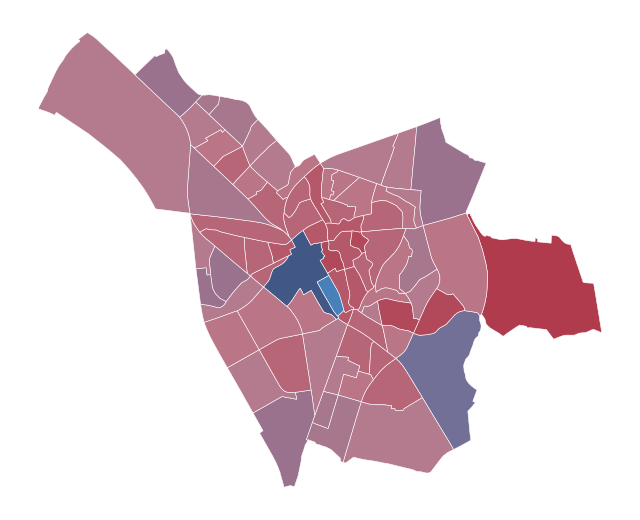

In [37]:
#choropleth map of transport vulnerability
fig, ax = plt.subplots(figsize=(8, 8))

plot = study_area.plot(
    column='transport_vulnerability_scaled',
    cmap=cmap,
    edgecolor='white',
    linewidth=0.4,
    #legend=True,
    legend_kwds={"shrink": 0.2},
    ax=ax
)

'''
cbar = plot.get_figure().axes[1]
cbar.set_yticks([0, 0.5, 1])
cbar.set_yticklabels(["Low vulnerability", "Medium", "High vulnerability"])
'''

ax.set_axis_off()

plt.show()


fig.savefig(
    "chloropleth_transport_vulnerability.png",
    dpi=600,
    bbox_inches="tight",
)


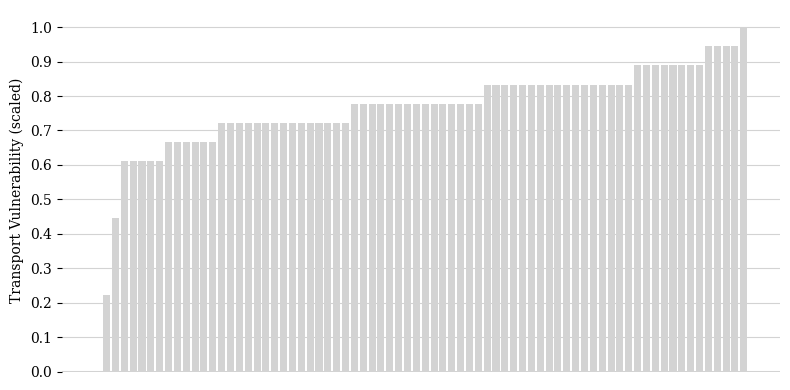

In [38]:
sorted_vulnerability = study_area.sort_values(by="transport_vulnerability_scaled")

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    sorted_vulnerability.index,
    sorted_vulnerability["transport_vulnerability_scaled"],
    color = 'lightgrey'
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.axhline(0, color='lightgrey',zorder=0)

# Add horizontal lines (grid lines)
ax.grid(visible=True, axis='y',color='lightgrey')
ax.set_axisbelow(True)

ax.set_ylabel("Transport Vulnerability (scaled)")
yticks = np.arange(0, 1.1, 0.1)
ax.set_yticks(yticks)

ax.set_xticks([])

plt.tight_layout()
plt.show()



fig.savefig(
    "barchart_vulnerability.png",
    dpi=600,
    bbox_inches="tight",
)


### Equity Plots

In [39]:
'''
#choropleth map of equity
fig, ax = plt.subplots(figsize=(8, 8))

study_area.plot(
    column='equity_score_scaled',
    cmap='YlGnBu',
    edgecolor='black',
    linewidth=1,
    legend=True,
    legend_kwds={
        "shrink": 0.2,
        "ticks": [0, 0.5, 1],
    },
    ax=ax
)

ax.set_axis_off()

plt.show()


fig.savefig(
    "chloropleth_equity.png",
    dpi=600,
    bbox_inches="tight",
)
'''

'\n#choropleth map of equity\nfig, ax = plt.subplots(figsize=(8, 8))\n\nstudy_area.plot(\n    column=\'equity_score_scaled\',\n    cmap=\'YlGnBu\',\n    edgecolor=\'black\',\n    linewidth=1,\n    legend=True,\n    legend_kwds={\n        "shrink": 0.2,\n        "ticks": [0, 0.5, 1],\n    },\n    ax=ax\n)\n\nax.set_axis_off()\n\nplt.show()\n\n\nfig.savefig(\n    "chloropleth_equity.png",\n    dpi=600,\n    bbox_inches="tight",\n)\n'

In [40]:
'''
sorted_equity = study_area.sort_values(by="equity_score_scaled")

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    sorted_equity.index,
    sorted_equity["equity_score_scaled"],
    color = 'grey'
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.axhline(0, color='lightgrey',zorder=0)

# Add horizontal lines (grid lines)
ax.grid(visible=True, axis='y',color='lightgrey')
ax.set_axisbelow(True)

#ax.set_ylabel("Accessibility Score (Normalised)")
yticks = np.arange(0, 1.1, 0.1)
ax.set_yticks(yticks)

ax.set_xticks([])

plt.tight_layout()
plt.show()
'''

'''
fig.savefig(
    "barchart_equity.png",
    dpi=600,
    bbox_inches="tight",
)
'''

'\nfig.savefig(\n    "barchart_equity.png",\n    dpi=600,\n    bbox_inches="tight",\n)\n'

### Priority Plots

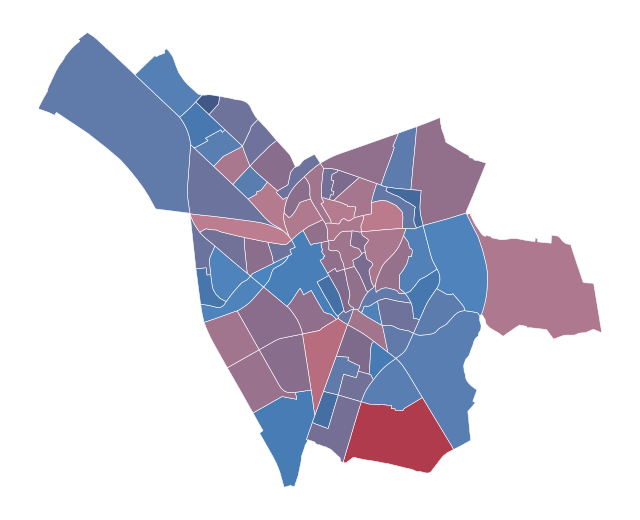

In [41]:
#choropleth map of priority
fig, ax = plt.subplots(figsize=(8, 8))

plot = study_area.plot(
    column='priority_score_scaled',
    cmap=cmap,
    edgecolor='white',
    linewidth=0.4,
    #legend=True,
    legend_kwds={"shrink": 0.2},
    ax=ax
)

'''
cbar = plot.get_figure().axes[1]
cbar.set_yticks([0, 0.5, 1])
cbar.set_yticklabels(["Low priority", "Medium", "High priority"])
'''
ax.set_axis_off()

plt.show()


fig.savefig(
    "chloropleth_priority.png",
    dpi=600,
    bbox_inches="tight",
)


In [42]:
'''
sorted_priority = study_area.sort_values(by="priority_score_scaled")

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    sorted_priority.index,
    sorted_priority["priority_score_scaled"],
    color = 'grey'
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.axhline(0, color='lightgrey',zorder=0)

# Add horizontal lines (grid lines)
ax.grid(visible=True, axis='y',color='lightgrey')
ax.set_axisbelow(True)

#ax.set_ylabel("Accessibility Score (Normalised)")
yticks = np.arange(0, 1.1, 0.1)
ax.set_yticks(yticks)

ax.set_xticks([])

plt.tight_layout()
plt.show()
'''

'''
fig.savefig(
    "barchart_priority.png",
    dpi=600,
    bbox_inches="tight",
)
'''

'\nfig.savefig(\n    "barchart_priority.png",\n    dpi=600,\n    bbox_inches="tight",\n)\n'

## Download files

In [43]:

#export network
nodes.to_file("cycle_nodes.gpkg", driver="GPKG")
edges.to_file("cycle_edges.gpkg", driver="GPKG")
buffer_gdf.to_file("cycle_buffer.gpkg", driver="GPKG")

study_area.to_file(f"{scale}_analysis.gpkg", driver="GPKG")

'''
files.download("cycle_nodes.gpkg")
files.download("cycle_edges.gpkg")
files.download("cycle_buffer.gpkg")

files.download(f"{scale}_analysis.gpkg")
'''

'\nfiles.download("cycle_nodes.gpkg")\nfiles.download("cycle_edges.gpkg")\nfiles.download("cycle_buffer.gpkg")\n\nfiles.download(f"{scale}_analysis.gpkg")\n'